<a href="https://colab.research.google.com/github/Vishalization/Skin_Disease_Classification/blob/main/Vishal_EfficientNet_Improvement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:


from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/skin_split.rar" /content/

In [ ]:
!ls /content

drive  sample_data  skin_split.rar


In [3]:
!apt-get install unrar
!unrar x /content/skin_split.rar /content/

Streaming output truncated to the last 5000 lines.
Extracting  /content/skin_split/train/nv/ISIC_0025194.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025198.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025200.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025201.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025202.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025203.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025204.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025205.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025206.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025207.jpg                 50%  OK 
Extracting  /content/skin_spl

In [20]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import sklearn

In [21]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import efficientnet
from tensorflow.keras.layers import Flatten, Dense, Input, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report
from tensorflow.keras.applications.efficientnet import preprocess_input


In [22]:
from tensorflow.keras.regularizers import l2

In [23]:
# path for training and testing data
train_dir = "/content/skin_split/train"
test_dir = "/content/skin_split/test"

In [24]:
# data augmentation for training data
train_datagen = ImageDataGenerator(
   preprocessing_function=preprocess_input,
   rotation_range=30,
   width_shift_range=0.1,
   height_shift_range=0.1,
   shear_range=0.1,
   zoom_range=0.2,
   horizontal_flip=True,
   fill_mode='nearest',
   validation_split=0.15
)

In [25]:
# generate data for training and validation data set
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42
)

Found 6813 images belonging to 7 classes.
Found 1197 images belonging to 7 classes.


In [26]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2005 images belonging to 7 classes.


In [27]:
#class weight as the HAM10000 is imbalance
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights using training labels
classes = np.unique(train_generator.classes)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(4.384169884169884), 1: np.float64(2.780816326530612), 2: np.float64(1.3011841100076393), 3: np.float64(12.320072332730561), 4: np.float64(1.2857142857142858), 5: np.float64(0.21343984962406015), 6: np.float64(10.033873343151694)}


In [29]:
# model download and configuration
from tensorflow.keras.applications import *
from tensorflow.keras.layers import Flatten, Dense, Input, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers :
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2)(x)
x = Dropout(0.5)(x)

#x = BatchNormalization()(x)
#x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
#x = Dropout(0.3)(x)

x = Dense(7, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=x)


tl_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 224, 224,  │          7 │ rescaling_6[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 224, 224,  │          0 │ normalization_3[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,384,426 (16.73 MB)

 Trainable params: 4,339,843 (16.56 MB)

 Non-trainable params: 44,583 (174.16 KB)

In [30]:
#optimizer
optimizer = Adam(0.0001)
tl_model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [31]:
# LearningRate; EarlyStopping; ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_efficent_skin_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [lr_reduce, early_stop, checkpoint]

In [32]:

#first training training or compiling
history = tl_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=12,
    callbacks=callbacks,
    class_weight=class_weights
)



Epoch 1/12
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 830ms/step - accuracy: 0.2123 - loss: 6.5228
Epoch 1: val_accuracy improved from None to 0.49958, saving model to best_efficent_skin_model.keras

Epoch 1: finished saving model to best_efficent_skin_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 296s 999ms/step - accuracy: 0.2859 - loss: 6.2072 - val_accuracy: 0.4996 - val_loss: 5.4542 - learning_rate: 1.0000e-04
Epoch 2/12
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.4270 - loss: 5.4562
Epoch 2: val_accuracy improved from 0.49958 to 0.66332, saving model to best_efficent_skin_model.keras

Epoch 2: finished saving model to best_efficent_skin_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 154s 724ms/step - accuracy: 0.4668 - loss: 5.3134 - val_accuracy: 0.6633 - val_loss: 4.8788 - learning_rate: 1.0000e-04
Epoch 3/12
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.5469 - loss: 4.9638
Epoch 3: val_accuracy improved from 0.66332 to 0.72013, saving model to best_efficent_skin_model.keras


In [33]:

# freeze most layers
for layer in base_model.layers[:-15]:
    layer.trainable = False

# unfreeze top layers
for layer in base_model.layers[-15:]:
    layer.trainable = True

from tensorflow.keras.optimizers import Adam

tl_model.compile(
 optimizer=Adam(1e-5),
 loss='categorical_crossentropy',
 metrics=['accuracy']
)

fine_tune_history = tl_model.fit(
 train_generator,
 validation_data=val_generator,
 epochs=10,
 callbacks=callbacks,
 class_weight=class_weights
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.8038 - loss: 2.4695
Epoch 1: val_accuracy improved from 0.80284 to 0.81871, saving model to best_efficent_skin_model.keras

Epoch 1: finished saving model to best_efficent_skin_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 198s 804ms/step - accuracy: 0.7973 - loss: 2.4477 - val_accuracy: 0.8187 - val_loss: 2.6219 - learning_rate: 1.0000e-05
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.7946 - loss: 2.4338
Epoch 2: val_accuracy did not improve from 0.81871
213/213 ━━━━━━━━━━━━━━━━━━━━ 144s 676ms/step - accuracy: 0.7989 - loss: 2.4209 - val_accuracy: 0.8070 - val_loss: 2.5989 - learning_rate: 1.0000e-05
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.8046 - loss: 2.3881
Epoch 3: val_accuracy did not improve from 0.81871
213/213 ━━━━━━━━━━━━━━━━━━━━ 145s 682ms/step - accuracy: 0.8054 - loss: 2.3737 - val_accuracy: 0.8087 - val_loss: 2.5880 - learning_rate: 1.0000e-05
Epoch 4/10
213/213

In [34]:
df=pd.DataFrame(tl_model.history.history)
df.to_csv('hist.csv')

<Axes: >

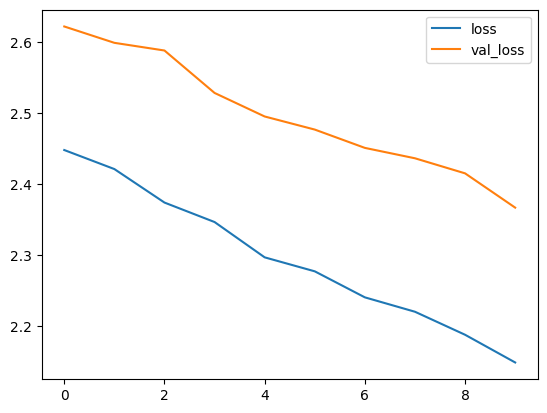

In [35]:
metrics = pd.DataFrame(tl_model.history.history)
metrics[["loss","val_loss"]].plot()

<Axes: >

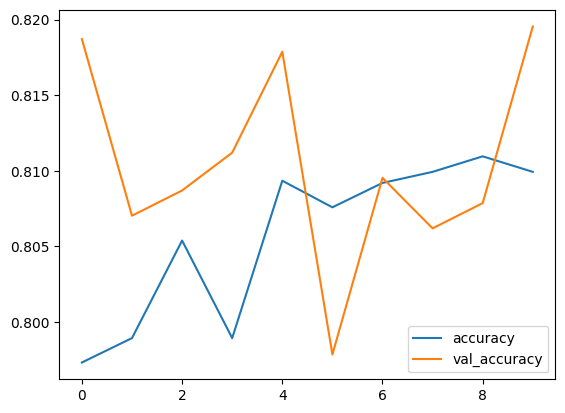

In [36]:
metrics[["accuracy","val_accuracy"]].plot()

In [37]:
tl_model.evaluate(test_generator)

63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 449ms/step - accuracy: 0.7002 - loss: 2.7767


[2.776656150817871, 0.7002493739128113]

In [38]:
predictions = tl_model.predict(test_generator, verbose=1)
predictions = predictions.argmax(axis=1)

test_labels = test_generator.classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 351ms/step


In [39]:
import sklearn
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(test_labels, predictions)

Normalized confusion matrix


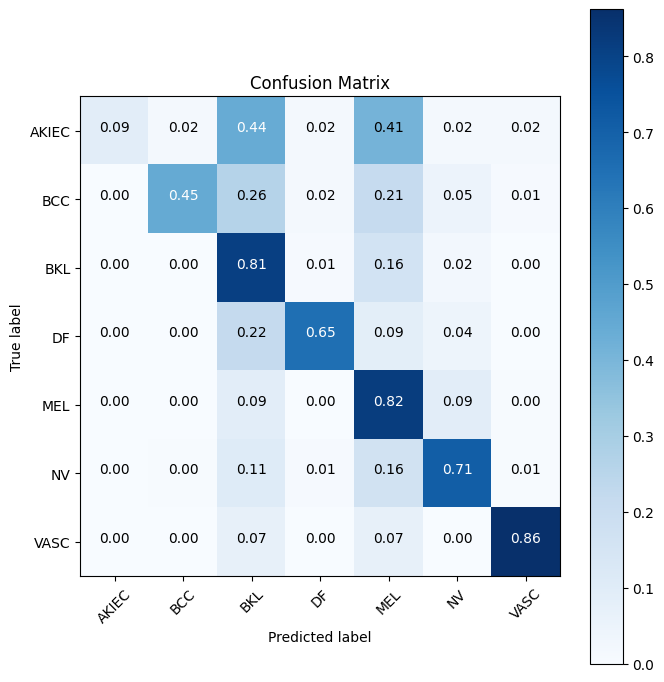

In [40]:
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=True,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
        print(cm)

    plt.figure(figsize=(7,7))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


cm_plot_labels =['AKIEC','BCC','BKL','DF','MEL','NV','VASC']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix', normalize=True)


In [41]:
!pip install disarray
import disarray

# Instantiate the confusion matrix DataFrame with index and columns
#cm = confusion_matrix(a,b)
df = pd.DataFrame(cm, index= ['AKIEC','BCC','BKL','DF','MEL','NV','VASC'], columns=['AKIEC','BCC','BKL','DF','MEL','NV','VASC'])
df.da.export_metrics()

,AKIEC,BCC,BKL,DF,MEL,NV,VASC,micro-average
accuracy,0.970075,0.968080,0.866334,0.988030,0.825935,0.790025,0.992020,0.914357
f1,0.166667,0.589744,0.570513,0.555556,0.510519,0.818925,0.757576,0.700249
false_discovery_rate,0.000000,0.132075,0.559406,0.516129,0.628571,0.032520,0.324324,0.299751
false_negative_rate,0.909091,0.553398,0.190909,0.347826,0.183857,0.290082,0.137931,0.299751
false_positive_rate,0.000000,0.003680,0.126611,0.008073,0.172840,0.048193,0.006073,0.049958
negative_predictive_value,0.969985,0.970799,0.973766,0.995947,0.972937,0.619001,0.997967,0.950042
positive_predictive_value,1.000000,0.867925,0.440594,0.483871,0.371429,0.967480,0.675676,0.700249
precision,1.000000,0.867925,0.440594,0.483871,0.371429,0.967480,0.675676,0.700249
recall,0.090909,0.446602,0.809091,0.652174,0.816143,0.709918,0.862069,0.700249
sensitivity,0.090909,0.446602,0.809091,0.652174,0.816143,0.709918,0.862069,0.700249


In [42]:
#downloading the best model
!zip skin_model.zip best_efficent_skin_model.keras
!ls
from google.colab import files
files.download("skin_model.zip")

  adding: best_efficent_skin_model.keras (deflated 10%)
best_efficent_skin_model.keras	hist.csv     skin_model.zip  skin_split.rar
drive				sample_data  skin_split


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>